# MEDIA MENSAL DE CADA INSUMO + CORRELAÇÃO ENTRE INSUMOS + R² & MAE

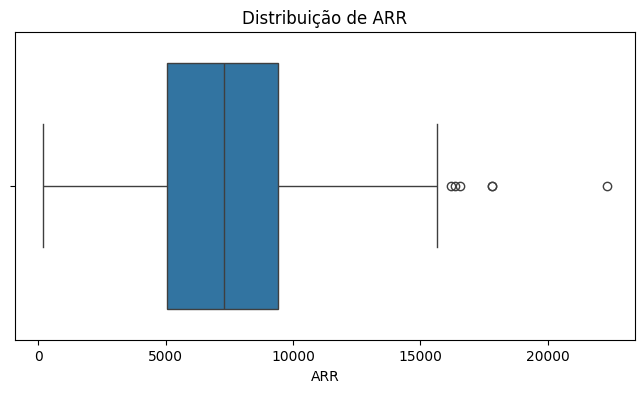

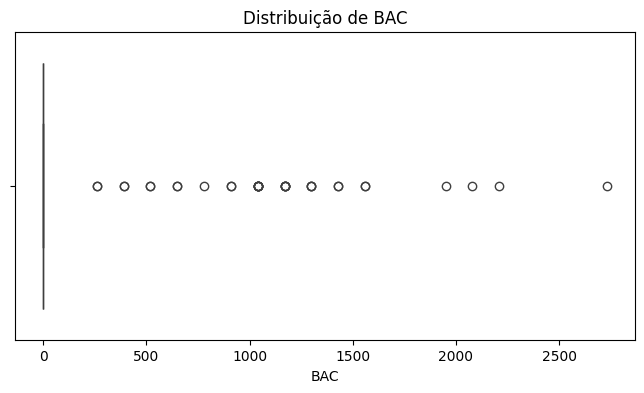

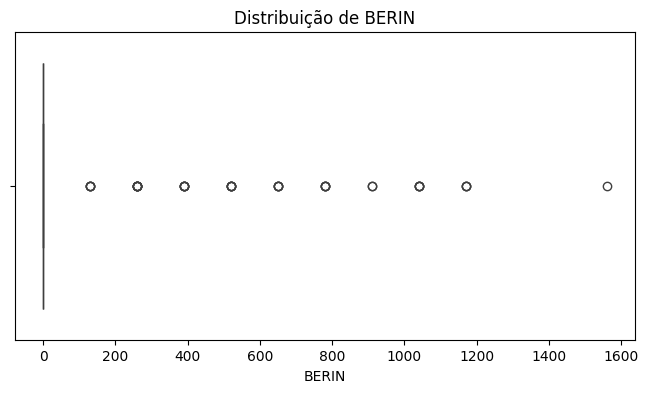

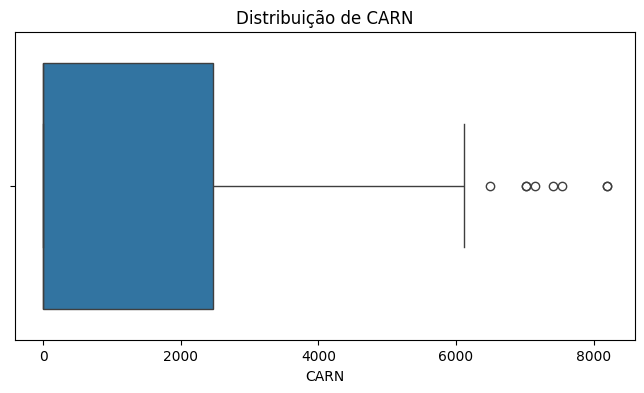

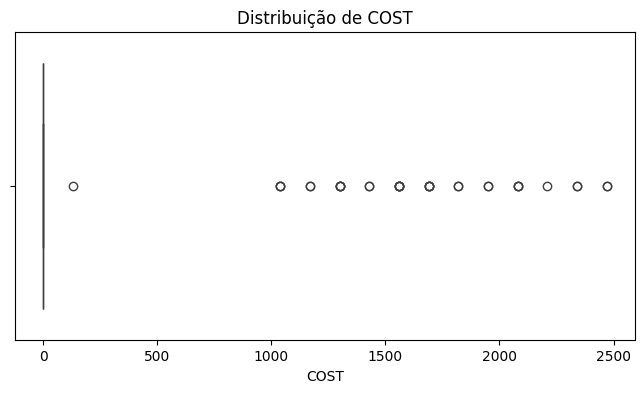

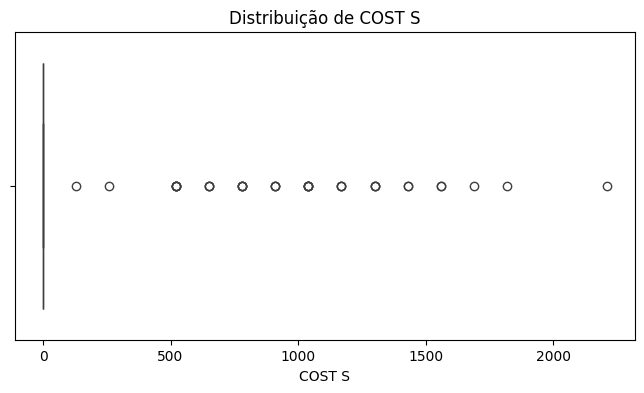

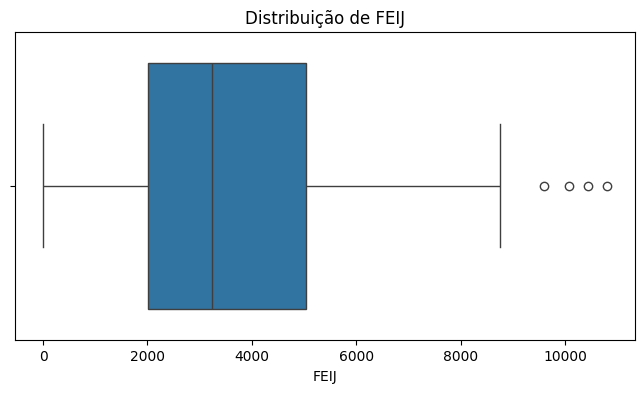

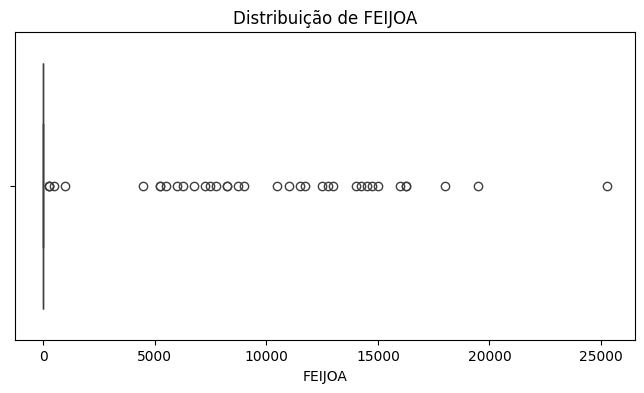

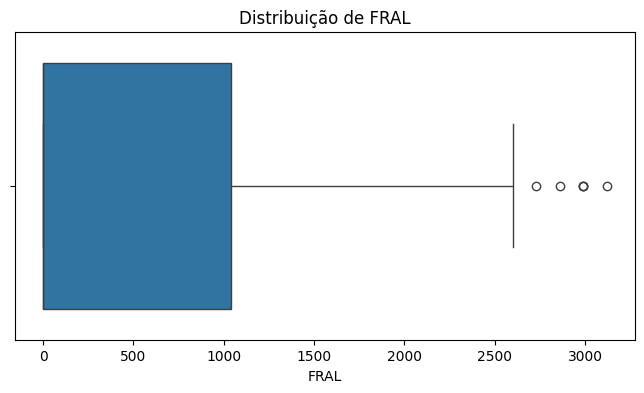

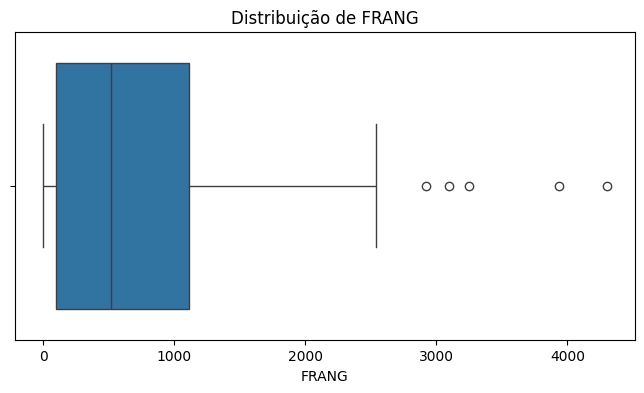

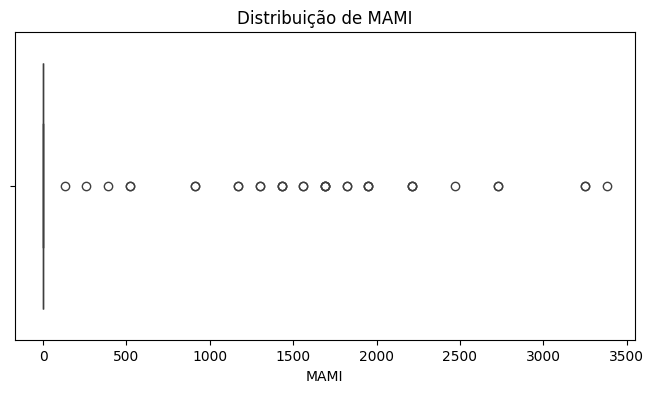

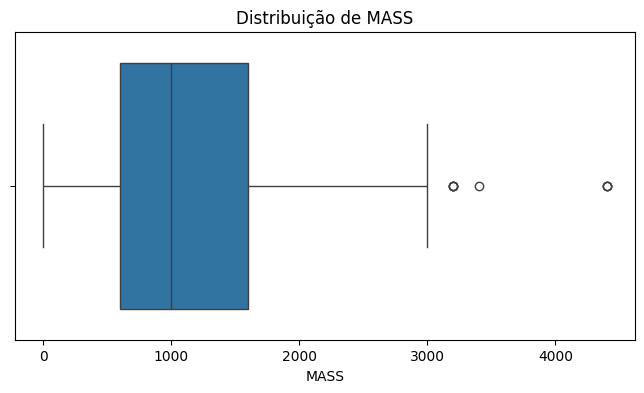

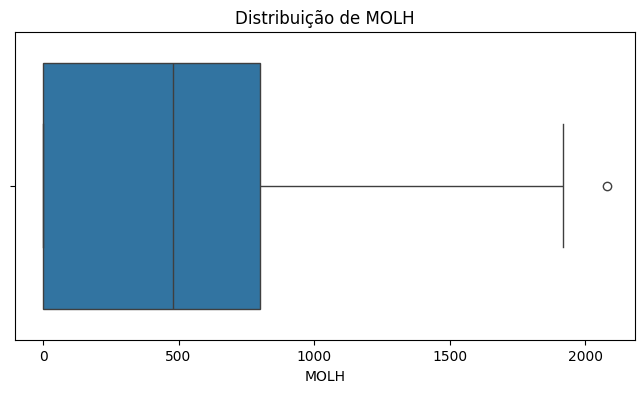

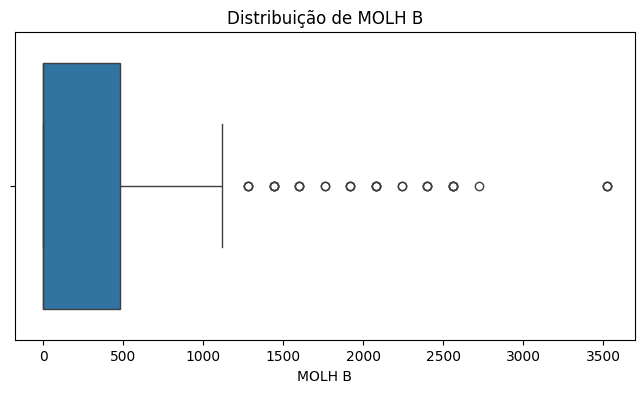

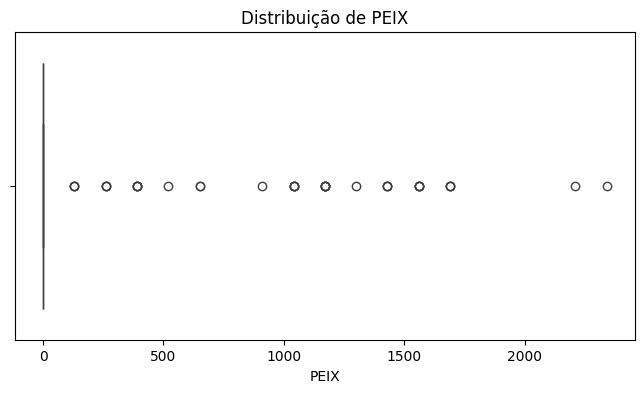

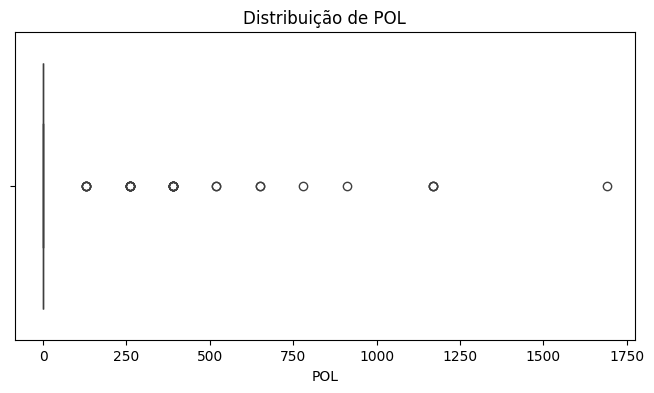

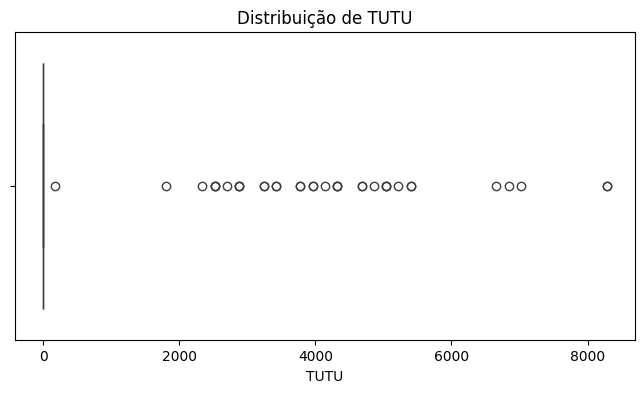

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Carregar dados
df = pd.read_excel("insumos_vendidos_por_dia.xlsx")
df.head()

# Converter data para datetime
df['data'] = pd.to_datetime(df['Data'])

# Extrair features temporais
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0 = segunda, 6 = domingo

# Remover NaNs
df.dropna(inplace=True)

#verificando outliers
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns  # Pega apenas colunas numéricas

for col in numerical_cols:
    plt.figure(figsize=(8, 4))  # Tamanho do gráfico
    sns.boxplot(data=df, x=col)
    plt.title(f'Distribuição de {col}')
    plt.show()

In [36]:
df

,Data,ARR,BAC,BERIN,CARN,COST,COST S,FEIJ,FEIJOA,FRAL,FRANG,MAMI,MASS,MOLH,MOLH B,PEIX,POL,TUTU,data,Dia_Semana
0,2024-03-12,7740,0,0,0,0,0,5160,0,0,1550,1950,1000,800,0,2210,0,0,2024-03-12,1
1,2024-03-13,12960,0,0,0,1560,0,2520,12750,0,1170,0,1000,800,0,0,0,0,2024-03-13,2
2,2024-03-14,6480,0,0,0,0,0,1680,0,1430,390,0,1400,160,960,0,650,3960,2024-03-14,3
3,2024-03-15,11520,1040,0,6110,0,910,7680,0,0,260,0,2800,0,2240,0,0,0,2024-03-15,4
4,2024-03-18,8820,0,390,3770,0,0,5880,0,2470,130,0,600,480,0,0,0,0,2024-03-18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2025-03-25,5580,0,0,130,0,0,3720,0,0,2110,1690,400,320,0,260,0,0,2025-03-25,1
176,2025-03-26,7740,0,0,0,1950,0,2640,5250,0,910,0,800,640,0,0,0,0,2025-03-26,2
177,2025-03-27,5040,0,0,0,0,0,1440,0,1040,520,0,800,640,0,0,0,2880,2025-03-27,3
178,2025-03-28,7920,1300,0,3770,0,520,5280,0,0,130,0,1000,0,800,0,0,0,2025-03-28,4


In [37]:
df = df.drop(columns=['data'])  # Remove a coluna extra

In [42]:
df

,Data,ARR,BAC,BERIN,CARN,COST,COST S,FEIJ,FEIJOA,FRAL,FRANG,MAMI,MASS,MOLH,MOLH B,PEIX,POL,TUTU,Dia_Semana,Mes
0,2024-03-12,7740,0,0,0,0,0,5160,0,0,1550,1950,1000,800,0,2210,0,0,1,3
1,2024-03-13,12960,0,0,0,1560,0,2520,12750,0,1170,0,1000,800,0,0,0,0,2,3
2,2024-03-14,6480,0,0,0,0,0,1680,0,1430,390,0,1400,160,960,0,650,3960,3,3
3,2024-03-15,11520,1040,0,6110,0,910,7680,0,0,260,0,2800,0,2240,0,0,0,4,3
4,2024-03-18,8820,0,390,3770,0,0,5880,0,2470,130,0,600,480,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2025-03-25,5580,0,0,130,0,0,3720,0,0,2110,1690,400,320,0,260,0,0,1,3
176,2025-03-26,7740,0,0,0,1950,0,2640,5250,0,910,0,800,640,0,0,0,0,2,3
177,2025-03-27,5040,0,0,0,0,0,1440,0,1040,520,0,800,640,0,0,0,2880,3,3
178,2025-03-28,7920,1300,0,3770,0,520,5280,0,0,130,0,1000,0,800,0,0,0,4,3


Análise Exploratória (EDA) Avançada

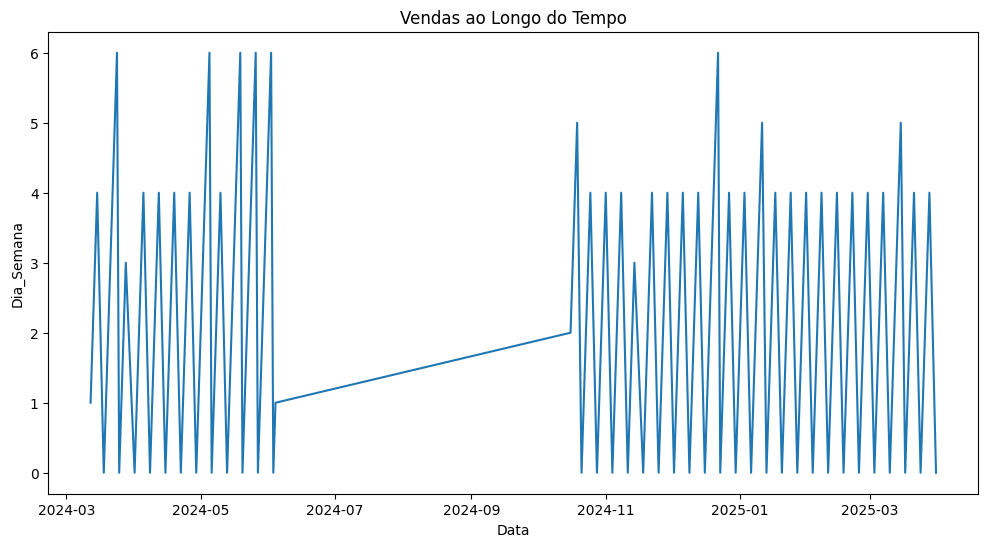

In [43]:
# Vendas ao longo do tempo
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Data', y='Dia_Semana')
plt.title('Vendas ao Longo do Tempo')
plt.show()

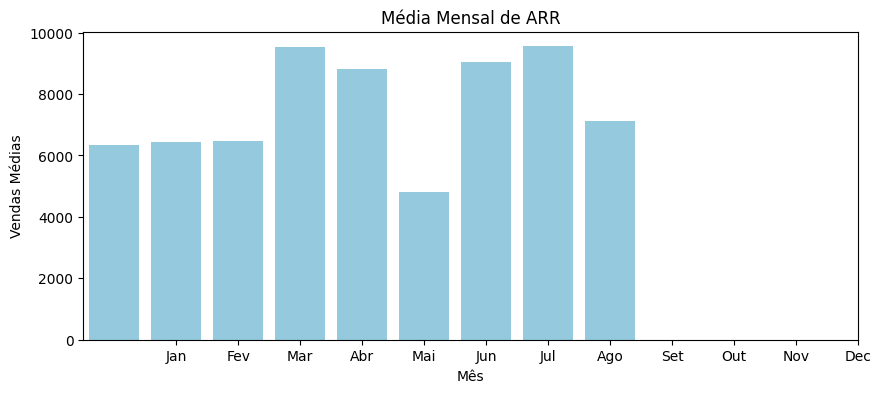

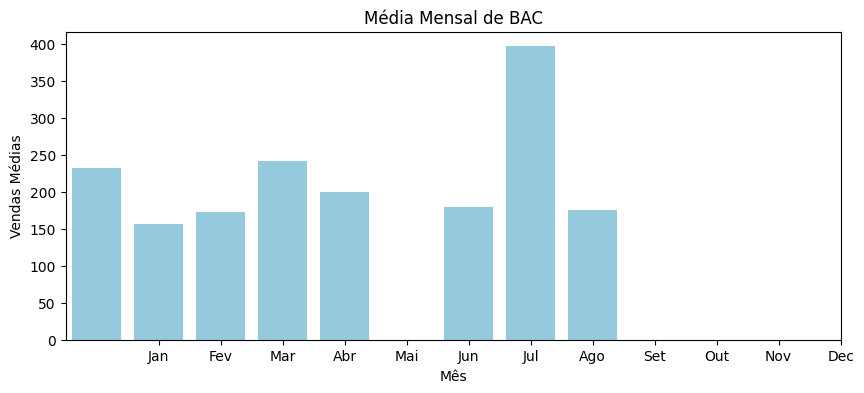

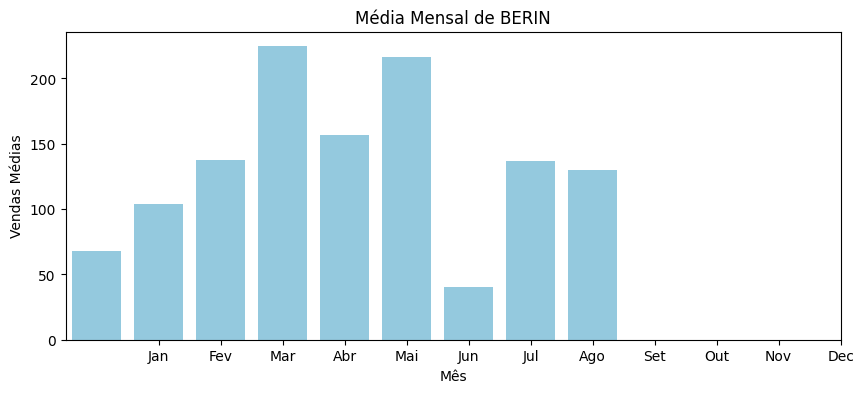

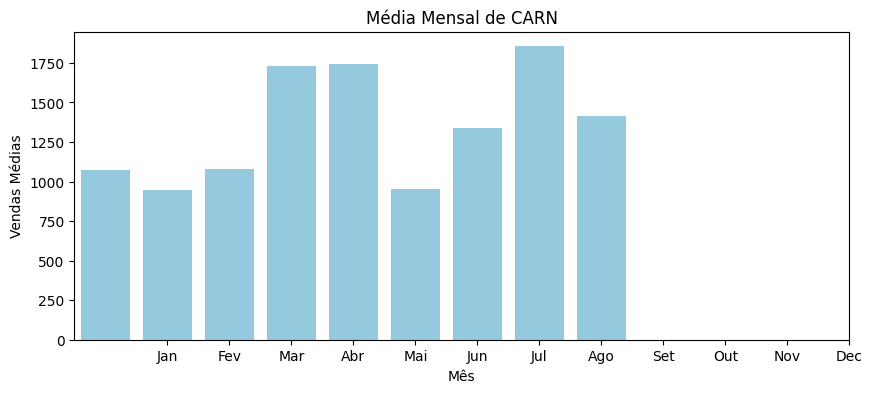

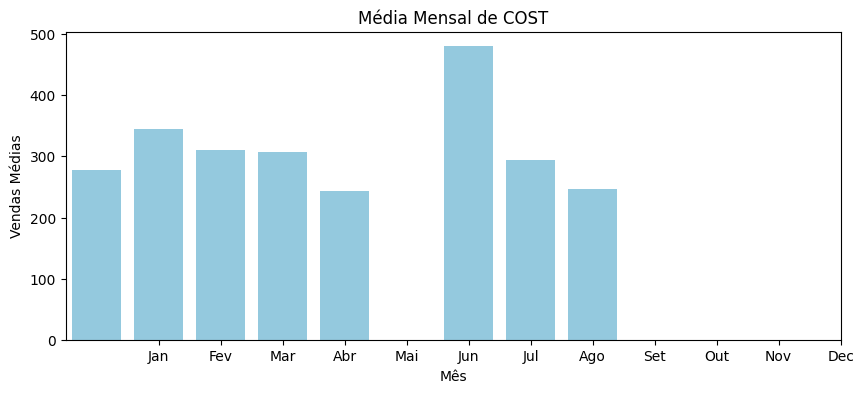

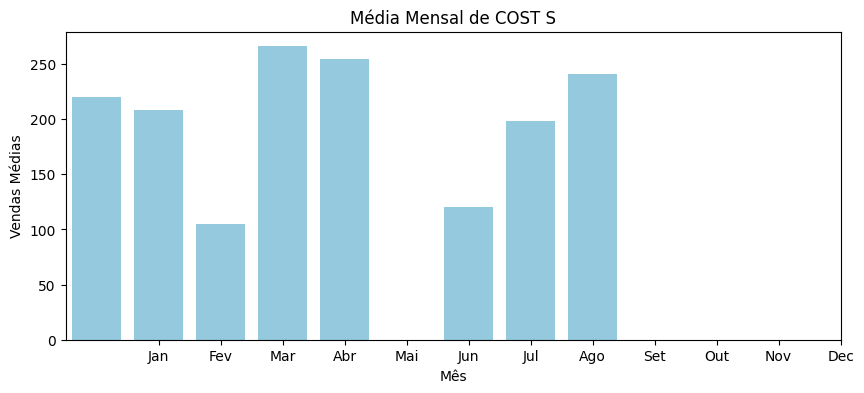

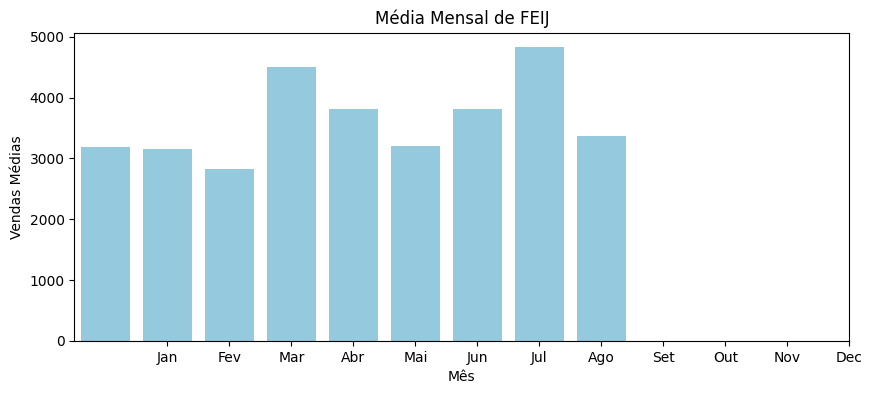

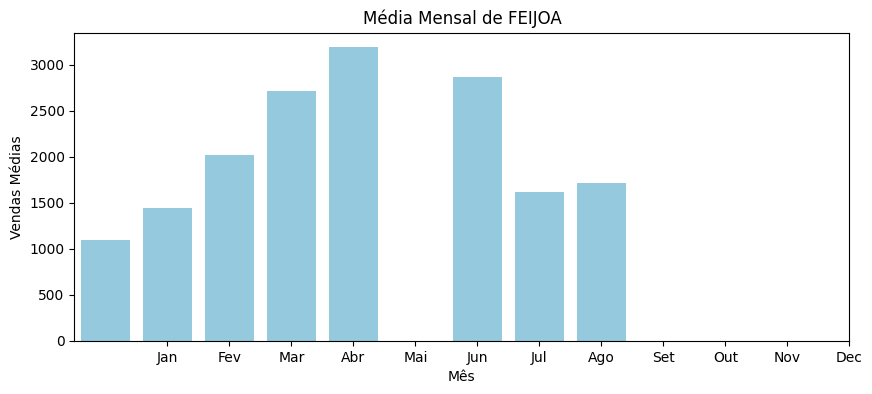

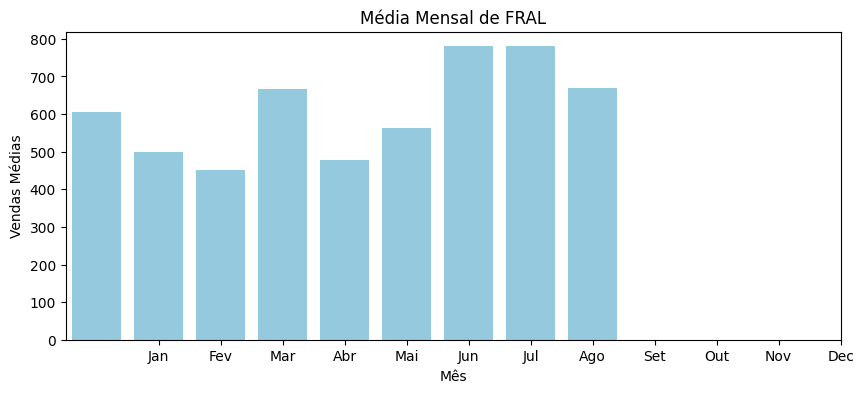

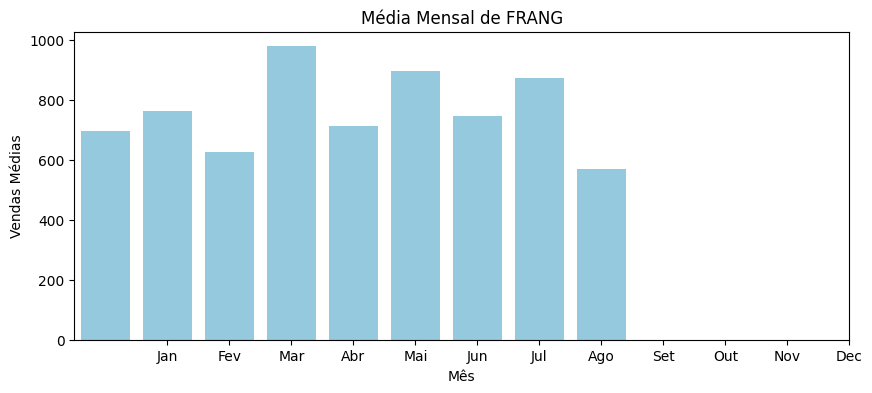

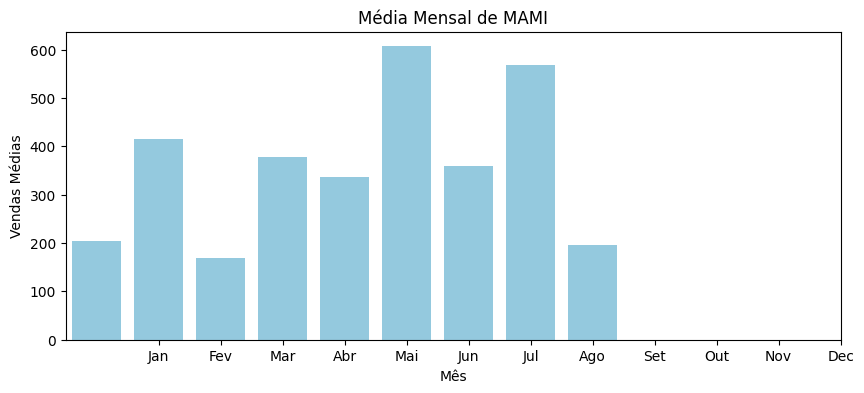

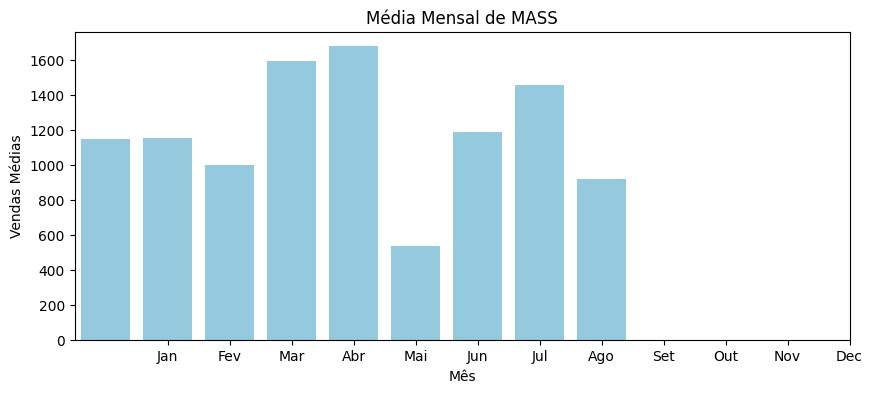

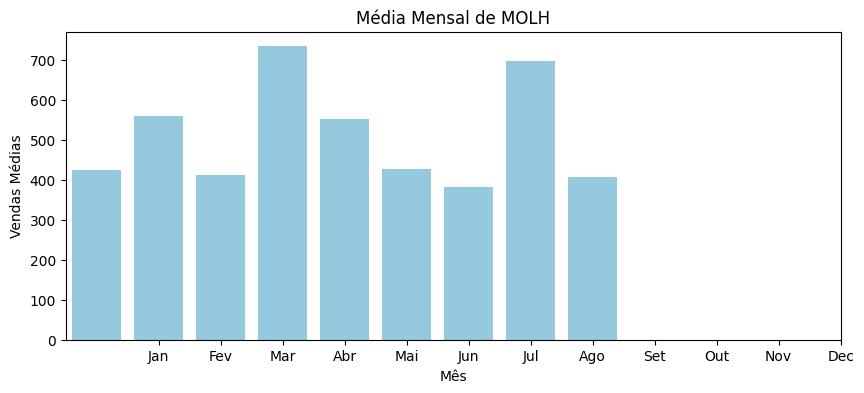

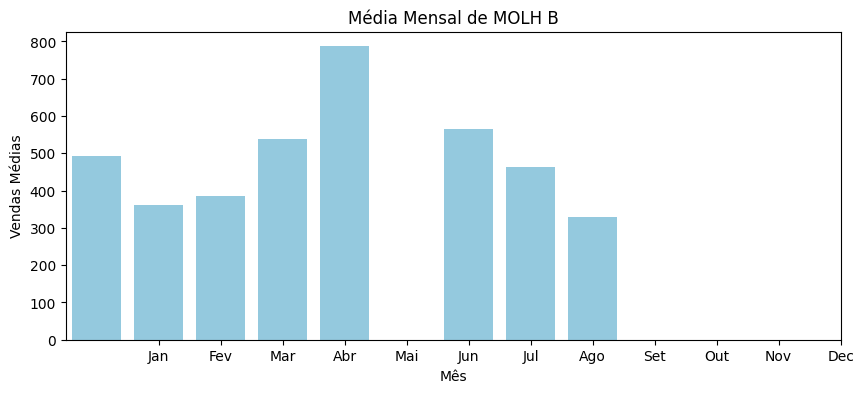

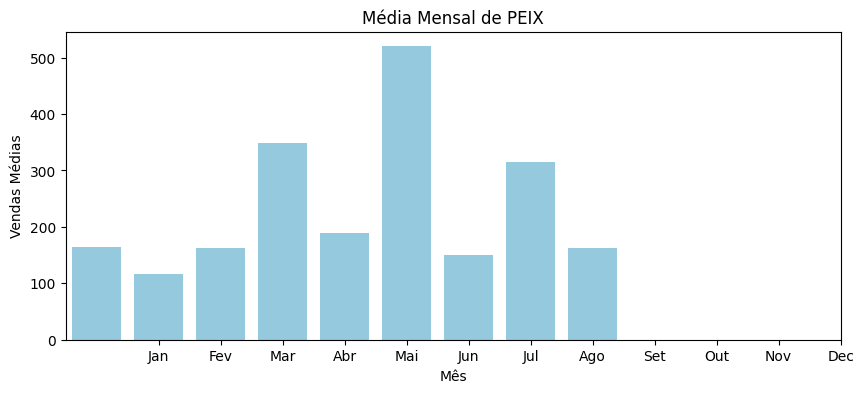

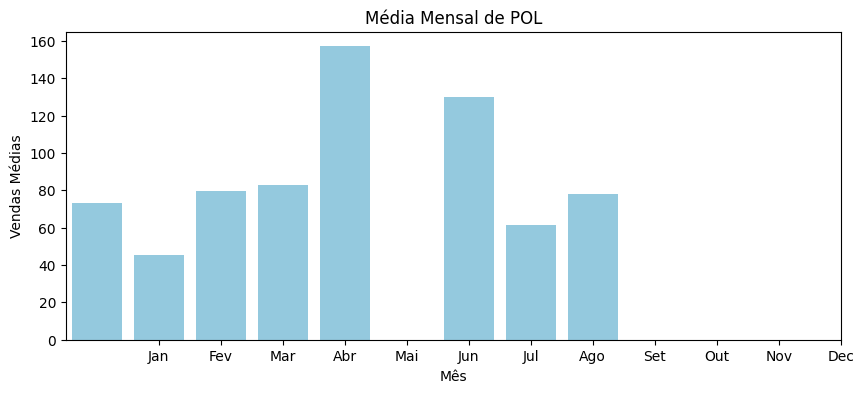

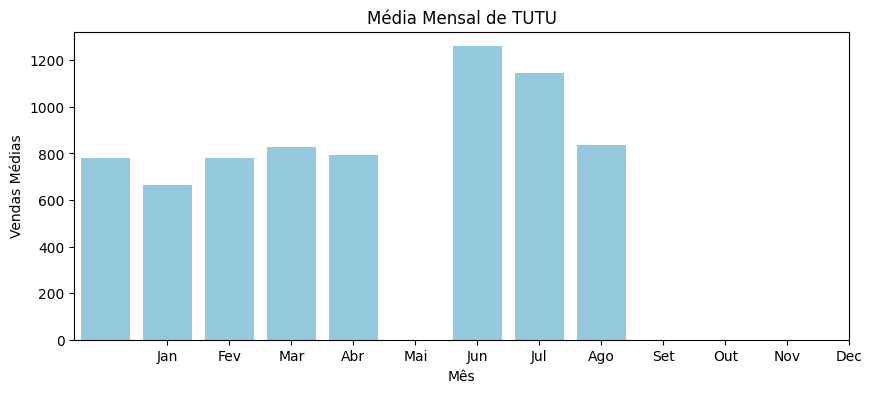

In [50]:

# Converter 'Data' para datetime e extrair mês
df['Data'] = pd.to_datetime(df['Data'])
df['Mes'] = df['Data'].dt.month

# Selecionar colunas de insumos (colunas 2 a 18)
insumos = df.columns[1:18]  # Pula a coluna 1 ('Data') e pega até a 18 ('TUTU')

# Loop para cada insumo
for insumo in insumos:
    media_mensal = df.groupby('Mes')[insumo].mean()
    
    plt.figure(figsize=(10, 4))
    sns.barplot(x=media_mensal.index, y=media_mensal.values, color='skyblue')
    plt.title(f'Média Mensal de {insumo}')
    plt.xlabel('Mês')
    plt.ylabel('Vendas Médias')
    plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                                          'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dec'])  # Nomes dos meses
    plt.show()

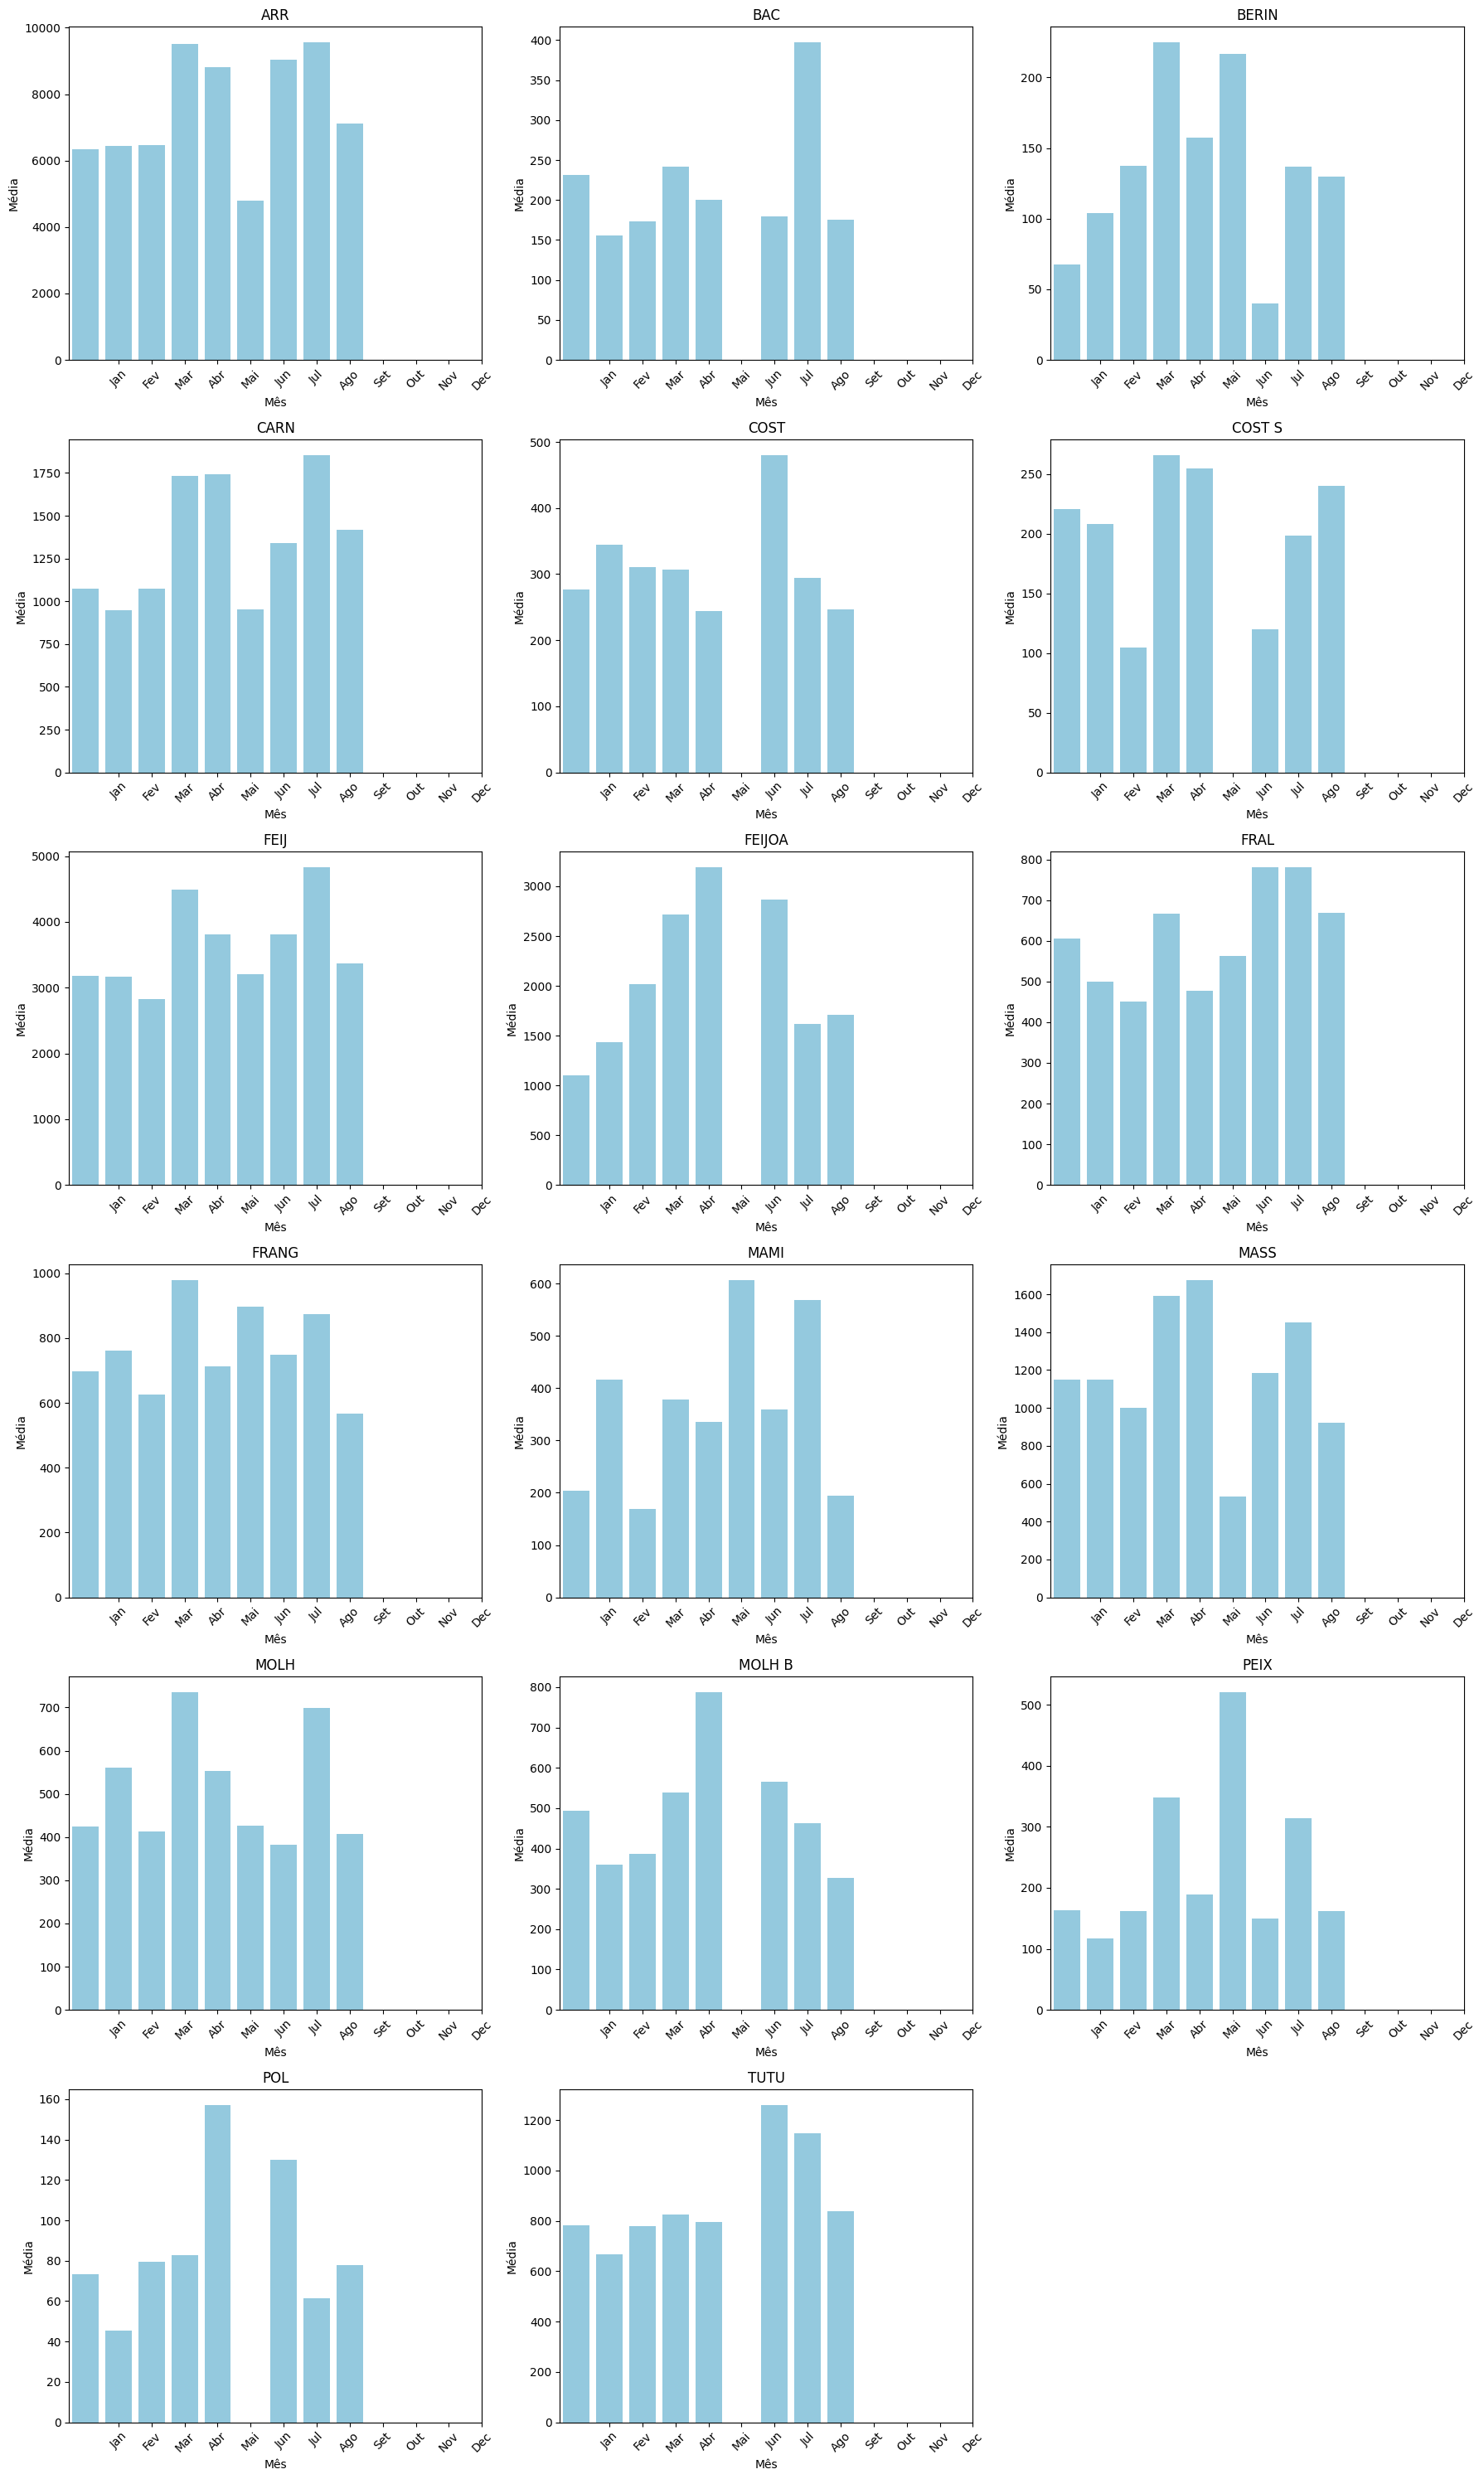

In [52]:
# Configurar o grid de subplots
n_cols = 3  # Número de colunas no grid
n_rows = (len(insumos) // n_cols) + 1  # Calcula linhas necessárias

plt.figure(figsize=(18, 5 * n_rows))  # Ajuste o tamanho conforme necessário

for i, insumo in enumerate(insumos, 1):
    media_mensal = df.groupby('Mes')[insumo].mean()
    
    plt.subplot(n_rows, n_cols, i)
    sns.barplot(x=media_mensal.index, y=media_mensal.values, color='skyblue')
    plt.title(insumo)
    plt.xlabel('Mês')
    plt.ylabel('Média')
    plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                                          'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dec'], rotation=45)

plt.tight_layout()  # Evita sobreposição
plt.show()

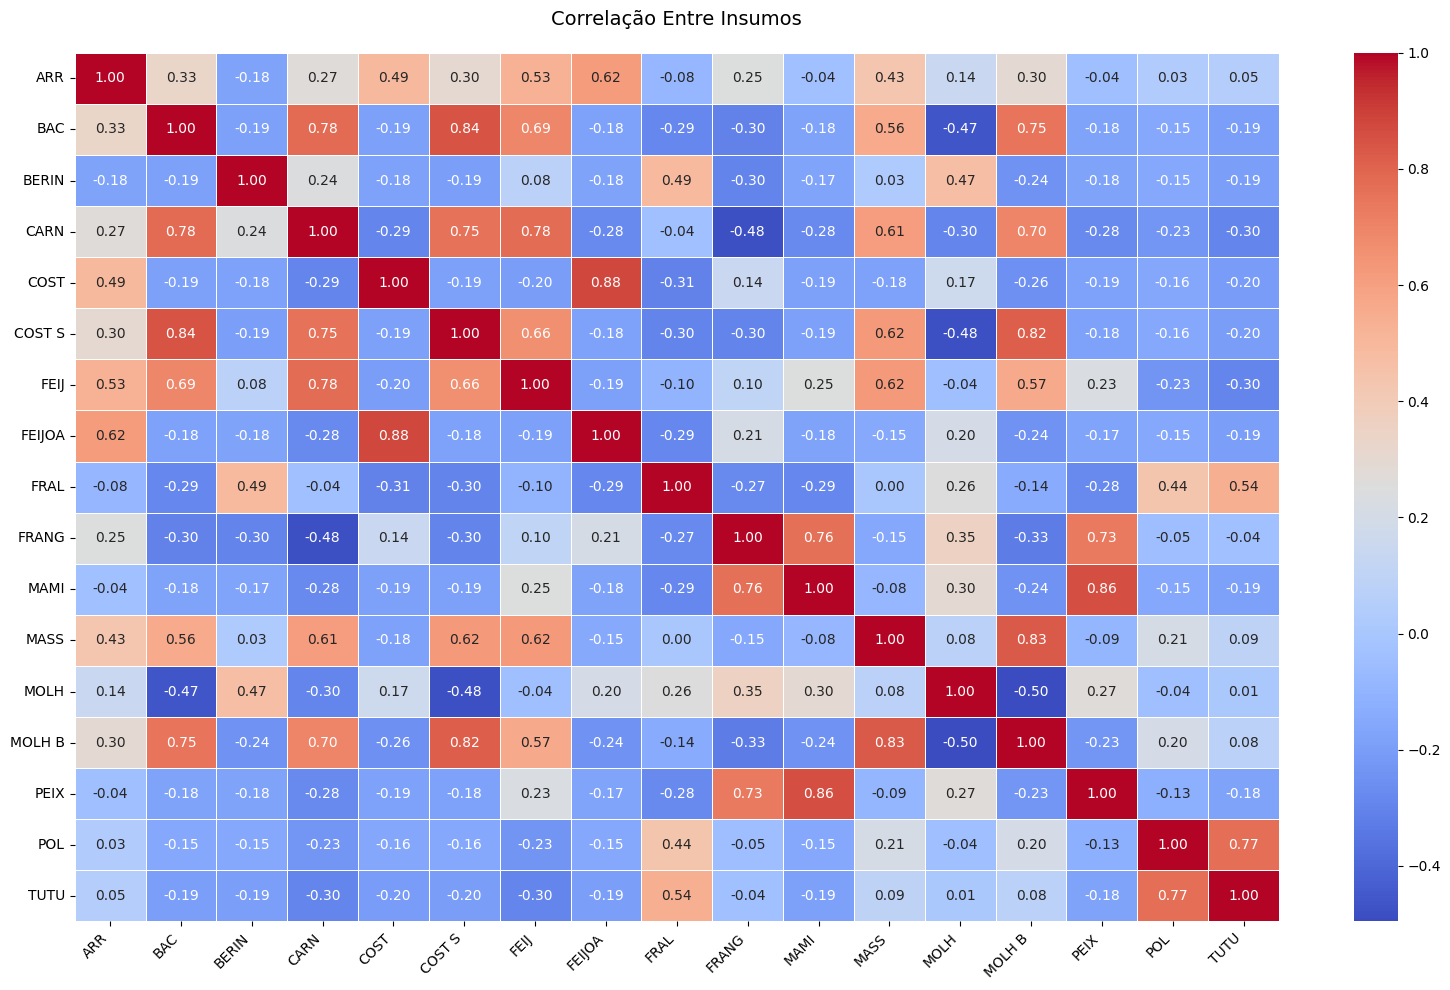

In [51]:
#CORRELAÇÃO ENTRE VARIÁVEIS

insumos = df.columns[1:18]  # Colunas de ARR até TUTU
corr_matrix = df[insumos].corr()

plt.figure(figsize=(16, 10)) 
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",  # Formato das anotações (2 casas decimais)
    linewidths=0.5,  # Linhas divisórias mais finas
    annot_kws={"size": 10}  # Tamanho da fonte das anotações
)
plt.title('Correlação Entre Insumos', fontsize=14, pad=20)  # Título com padding
plt.xticks(rotation=45, ha='right')  # Rotaciona labels do eixo X para melhor legibilidade
plt.yticks(rotation=0)  # Mantém labels do eixo Y horizontais
plt.tight_layout()  # Evita cortes nos labels
plt.show()

In [53]:
df

,Data,ARR,BAC,BERIN,CARN,COST,COST S,FEIJ,FEIJOA,FRAL,FRANG,MAMI,MASS,MOLH,MOLH B,PEIX,POL,TUTU,Dia_Semana,Mes
0,2024-03-12,7740,0,0,0,0,0,5160,0,0,1550,1950,1000,800,0,2210,0,0,1,3
1,2024-03-13,12960,0,0,0,1560,0,2520,12750,0,1170,0,1000,800,0,0,0,0,2,3
2,2024-03-14,6480,0,0,0,0,0,1680,0,1430,390,0,1400,160,960,0,650,3960,3,3
3,2024-03-15,11520,1040,0,6110,0,910,7680,0,0,260,0,2800,0,2240,0,0,0,4,3
4,2024-03-18,8820,0,390,3770,0,0,5880,0,2470,130,0,600,480,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,2025-03-25,5580,0,0,130,0,0,3720,0,0,2110,1690,400,320,0,260,0,0,1,3
176,2025-03-26,7740,0,0,0,1950,0,2640,5250,0,910,0,800,640,0,0,0,0,2,3
177,2025-03-27,5040,0,0,0,0,0,1440,0,1040,520,0,800,640,0,0,0,2880,3,3
178,2025-03-28,7920,1300,0,3770,0,520,5280,0,0,130,0,1000,0,800,0,0,0,4,3


In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Carregar os dados
df = pd.read_excel('insumos_vendidos_por_dia.xlsx')  # Ajuste o nome do arquivo
df['Data'] = pd.to_datetime(df['Data'])

# Extrair features temporais
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia'] = df['Data'].dt.day
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo

# Colunas de insumos (ARR, BAC, ..., TUTU)
insumos = df.columns[1:18]  # Pula 'Data' e pega até 'TUTU'

from sklearn.model_selection import train_test_split

# Definir features (X) e target (y)
X = df[['Ano', 'Mes', 'Dia', 'Dia_Semana']]  # Variáveis temporais
y = df['ARR']  # Alvo: vendas do insumo ARR

# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)  # shuffle=False para séries temporais

results = {}
for insumo in insumos:
    y = df[insumo]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    # Treinar modelo
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # Previsões e métricas
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[insumo] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

# Métricas
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.2f}")

MAE: 917.65
R²: 0.03
